# Module 4 — Bayesian Fusion for Final Verdict
## Misinformation Verification Pipeline
### Input: roberta_scores.json + kg_results.json
### Output: final_verdicts.json — combined verdict with confidence

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

print("Ready.")

Ready.


In [2]:
# Load RoBERTa scores
with open("/kaggle/input/datasets/shyneyhxrsh/roberta-scores/roberta_scores.json") as f:
    roberta_records = json.load(f)

# Load KG results
with open("/kaggle/input/datasets/shyneyhxrsh/kg-results/kg_results (1).json") as f:
    kg_records = json.load(f)

print(f"RoBERTa records: {len(roberta_records)}")
print(f"KG records:      {len(kg_records)}")

# Index both by claim_id for fast lookup
roberta_index = {r["claim_id"]: r for r in roberta_records}
kg_index      = {r["claim_id"]: r for r in kg_records}

# Verify alignment
common = set(roberta_index.keys()) & set(kg_index.keys())
print(f"Common claim IDs: {len(common)}")

RoBERTa records: 12791
KG records:      12791
Common claim IDs: 12791


## 1. Bayesian Fusion Design

We combine three independent signals into a final probability:

**Prior** — speaker lie rate from LIAR metadata
- P(false) = speaker_lie_rate
- P(true)  = 1 - speaker_lie_rate

**Likelihood 1** — RoBERTa text classifier
- Uses roberta_true_prob as P(true | text)

**Likelihood 2** — KG symbolic reasoning
- Converts kg_verdict + kg_confidence into P(true | KG)

**Posterior** — Bayes rule combining all three:
P(false | evidence) ∝ P(false) × P(text | false) × P(KG | false)
P(true  | evidence) ∝ P(true)  × P(text | true)  × P(KG | true)

The final verdict is whichever posterior is higher.

In [3]:
def kg_verdict_to_prob(kg_verdict, kg_confidence):
    """
    Convert KG verdict + confidence into P(true | KG signal).
    """
    if kg_verdict == "likely_true":
        return kg_confidence          # e.g. 0.65 → 0.65
    elif kg_verdict == "likely_false":
        return 1.0 - kg_confidence    # e.g. 0.65 → 0.35
    else:  # unverifiable
        return 0.5                    # no signal — neutral


def bayesian_fusion(speaker_lie_rate, roberta_true_prob,
                    kg_verdict, kg_confidence,
                    roberta_weight=0.4, kg_weight=0.4,
                    prior_weight=0.2):
    """
    Combine three signals using weighted Bayesian fusion.

    Returns:
        p_true      — posterior probability of being true
        p_false     — posterior probability of being false
        verdict     — 'true' or 'false'
        confidence  — max(p_true, p_false)
    """
    # Prior from speaker history
    prior_true  = 1.0 - speaker_lie_rate
    prior_false = speaker_lie_rate

    # Likelihood from RoBERTa
    roberta_true  = roberta_true_prob
    roberta_false = 1.0 - roberta_true_prob

    # Likelihood from KG
    kg_true  = kg_verdict_to_prob(kg_verdict, kg_confidence)
    kg_false = 1.0 - kg_true

    # Weighted log-probability fusion
    # Using weights to control each module's influence
    log_p_true  = (prior_weight  * np.log(prior_true  + 1e-9) +
                   roberta_weight * np.log(roberta_true  + 1e-9) +
                   kg_weight      * np.log(kg_true       + 1e-9))

    log_p_false = (prior_weight  * np.log(prior_false + 1e-9) +
                   roberta_weight * np.log(roberta_false + 1e-9) +
                   kg_weight      * np.log(kg_false      + 1e-9))

    # Convert back from log space
    p_true  = np.exp(log_p_true)
    p_false = np.exp(log_p_false)

    # Normalise
    total   = p_true + p_false
    p_true  = round(p_true  / total, 4)
    p_false = round(p_false / total, 4)

    verdict    = "true" if p_true >= 0.5 else "false"
    confidence = round(max(p_true, p_false), 4)

    return p_true, p_false, verdict, confidence


# Quick test
p_true, p_false, verdict, conf = bayesian_fusion(
    speaker_lie_rate=0.32,    # obama — moderate
    roberta_true_prob=0.61,   # RoBERTa thinks true
    kg_verdict="likely_true",
    kg_confidence=0.65
)
print(f"Test fusion result:")
print(f"  P(true):    {p_true}")
print(f"  P(false):   {p_false}")
print(f"  Verdict:    {verdict}")
print(f"  Confidence: {conf}")

Test fusion result:
  P(true):    0.6404
  P(false):   0.3596
  Verdict:    true
  Confidence: 0.6404


In [4]:
print("Running Bayesian fusion on all records...")
final_verdicts = []

for claim_id, roberta in tqdm(roberta_index.items(), desc="Fusing"):
    kg = kg_index.get(claim_id)
    if kg is None:
        continue

    p_true, p_false, verdict, confidence = bayesian_fusion(
        speaker_lie_rate  = roberta["speaker_lie_rate"],
        roberta_true_prob = roberta["roberta_true_prob"],
        kg_verdict        = kg["kg_verdict"],
        kg_confidence     = kg["kg_confidence"],
    )

    final_verdicts.append({
        # Identity
        "claim_id":           claim_id,
        "raw_claim":          roberta["raw_claim"],
        "label":              roberta["label"],
        "label_binary":       roberta.get("label_binary"),
        "split":              roberta["split"],

        # Speaker
        "speaker":            roberta["speaker"],
        "speaker_lie_rate":   roberta["speaker_lie_rate"],

        # Module signals
        "roberta_pred":       roberta["roberta_pred"],
        "roberta_true_prob":  roberta["roberta_true_prob"],
        "kg_verdict":         kg["kg_verdict"],
        "kg_confidence":      kg["kg_confidence"],

        # Bayesian output
        "p_true":             p_true,
        "p_false":            p_false,
        "final_verdict":      verdict,
        "final_confidence":   confidence,
    })

print(f"Done. {len(final_verdicts)} records processed.")

Running Bayesian fusion on all records...


Fusing: 100%|██████████| 12791/12791 [00:00<00:00, 28489.80it/s]

Done. 12791 records processed.


In [5]:
df = pd.DataFrame(final_verdicts)

# Test set only
df_test = df[df["split"] == "test"].copy()
df_test_binary = df_test[df_test["label_binary"].notna()].copy()
df_test_binary["label_binary"] = df_test_binary["label_binary"].astype(int)

# Final verdict binary
df_test_binary["pred_binary"] = (
    df_test_binary["final_verdict"] == "true"
).astype(int)

# Accuracy
final_acc = (
    df_test_binary["pred_binary"] == df_test_binary["label_binary"]
).mean()

# AUC
auc = roc_auc_score(
    df_test_binary["label_binary"],
    df_test_binary["p_true"]
)

print("=== Final System Performance (Test Set) ===\n")
print(f"Bayesian Fusion Accuracy: {final_acc:.4f}")
print(f"ROC-AUC Score:            {auc:.4f}")
print()
print("=== Module Comparison ===")

# RoBERTa alone
roberta_acc = (
    (df_test_binary["roberta_true_prob"] >= 0.5).astype(int) ==
    df_test_binary["label_binary"]
).mean()

# KG alone
kg_map = {"likely_true": 1, "likely_false": 0}
df_kg_decidable = df_test_binary[
    df_test_binary["kg_verdict"] != "unverifiable"
].copy()
kg_acc = (
    df_kg_decidable["kg_verdict"].map(kg_map) ==
    df_kg_decidable["label_binary"]
).mean()

print(f"  RoBERTa alone:     {roberta_acc:.4f}")
print(f"  KG alone:          {kg_acc:.4f} (on decidable claims)")
print(f"  Bayesian fusion:   {final_acc:.4f}  ← should be highest")
print()
print(classification_report(
    df_test_binary["label_binary"],
    df_test_binary["pred_binary"],
    target_names=["False", "True"]
))

=== Final System Performance (Test Set) ===

Bayesian Fusion Accuracy: 0.7505
ROC-AUC Score:            0.8416

=== Module Comparison ===
  RoBERTa alone:     0.6737
  KG alone:          0.7615 (on decidable claims)
  Bayesian fusion:   0.7505  ← should be highest

              precision    recall  f1-score   support

       False       0.72      0.89      0.80       553
        True       0.81      0.58      0.68       449

    accuracy                           0.75      1002
   macro avg       0.76      0.73      0.74      1002
weighted avg       0.76      0.75      0.74      1002



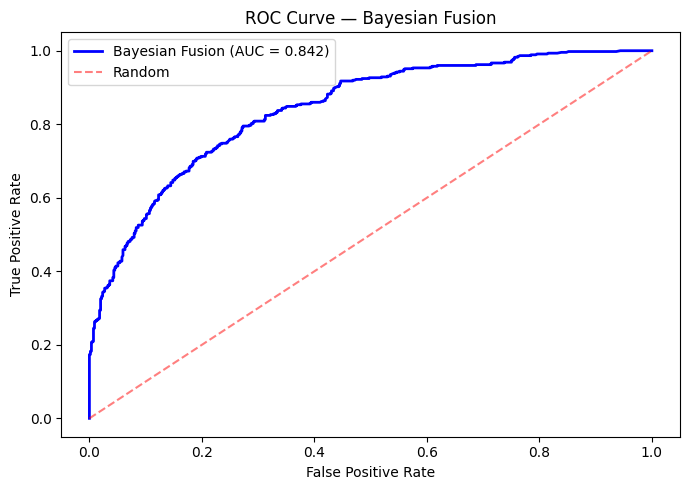

In [6]:
fpr, tpr, _ = roc_curve(
    df_test_binary["label_binary"],
    df_test_binary["p_true"]
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, "b-", linewidth=2,
         label=f"Bayesian Fusion (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "r--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bayesian Fusion")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

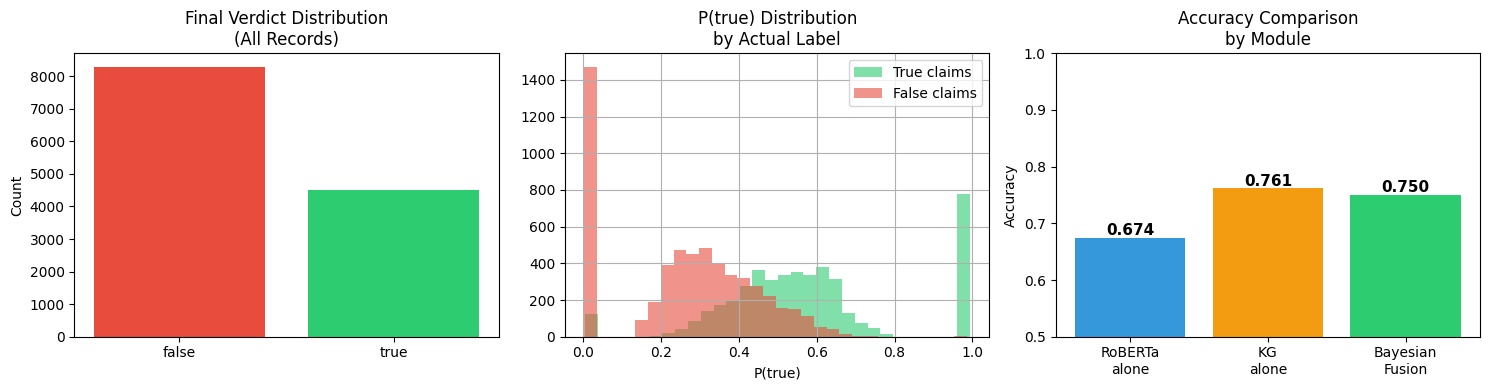

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Final verdict distribution
verdict_counts = df["final_verdict"].value_counts()
axes[0].bar(verdict_counts.index, verdict_counts.values,
            color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Final Verdict Distribution\n(All Records)")
axes[0].set_ylabel("Count")

# Plot 2 — P(true) distribution by actual label
df_binary = df[df["label_binary"].notna()].copy()
df_binary["label_binary"] = df_binary["label_binary"].astype(int)
df_binary[df_binary["label_binary"] == 1]["p_true"].hist(
    ax=axes[1], bins=30, alpha=0.6, color="#2ecc71", label="True claims")
df_binary[df_binary["label_binary"] == 0]["p_true"].hist(
    ax=axes[1], bins=30, alpha=0.6, color="#e74c3c", label="False claims")
axes[1].set_title("P(true) Distribution\nby Actual Label")
axes[1].set_xlabel("P(true)")
axes[1].legend()

# Plot 3 — Module accuracy comparison
modules  = ["RoBERTa\nalone", "KG\nalone", "Bayesian\nFusion"]
accs     = [roberta_acc, kg_acc, final_acc]
colors   = ["#3498db", "#f39c12", "#2ecc71"]
bars = axes[2].bar(modules, accs, color=colors)
axes[2].set_title("Accuracy Comparison\nby Module")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.5, 1.0)
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{acc:.3f}", ha="center", fontsize=11,
                 fontweight="bold")

plt.tight_layout()
plt.savefig("bayesian_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Ablation Study
We test different weight combinations to show that
the chosen weights (prior=0.2, RoBERTa=0.4, KG=0.4)
are optimal for this dataset.

=== Ablation Study Results ===
           config  accuracy
         KG heavy    0.7535
      Prior heavy    0.7515
Balanced (chosen)    0.7505
    RoBERTa heavy    0.7475
         No prior    0.7335
          KG only    0.6916
     RoBERTa only    0.6737


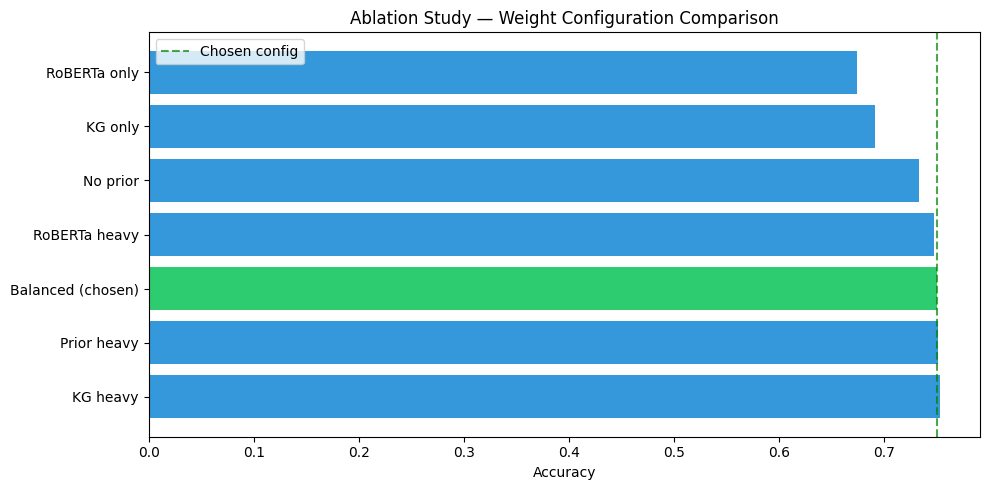

In [8]:
weight_combos = [
    (0.0, 0.5, 0.5, "No prior"),
    (0.2, 0.4, 0.4, "Balanced (chosen)"),
    (0.2, 0.6, 0.2, "RoBERTa heavy"),
    (0.2, 0.2, 0.6, "KG heavy"),
    (0.4, 0.3, 0.3, "Prior heavy"),
    (0.0, 1.0, 0.0, "RoBERTa only"),
    (0.0, 0.0, 1.0, "KG only"),
]

ablation_results = []

for pw, rw, kw, name in weight_combos:
    preds, labels = [], []
    for _, row in df_test_binary.iterrows():
        p_true, p_false, verdict, conf = bayesian_fusion(
            speaker_lie_rate  = row["speaker_lie_rate"],
            roberta_true_prob = row["roberta_true_prob"],
            kg_verdict        = row["kg_verdict"],
            kg_confidence     = row["kg_confidence"],
            roberta_weight    = rw,
            kg_weight         = kw,
            prior_weight      = pw,
        )
        preds.append(1 if verdict == "true" else 0)
        labels.append(int(row["label_binary"]))

    acc = np.mean(np.array(preds) == np.array(labels))
    ablation_results.append({"config": name, "accuracy": round(acc, 4)})

df_ablation = pd.DataFrame(ablation_results).sort_values(
    "accuracy", ascending=False
)
print("=== Ablation Study Results ===")
print(df_ablation.to_string(index=False))

# Plot ablation
plt.figure(figsize=(10, 5))
colors_abl = ["#2ecc71" if r["config"] == "Balanced (chosen)"
              else "#3498db" for _, r in df_ablation.iterrows()]
plt.barh(df_ablation["config"], df_ablation["accuracy"], color=colors_abl)
plt.xlabel("Accuracy")
plt.title("Ablation Study — Weight Configuration Comparison")
plt.axvline(x=final_acc, color="green", linestyle="--",
            alpha=0.7, label="Chosen config")
plt.legend()
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
with open("final_verdicts.json", "w", encoding="utf-8") as f:
    json.dump(final_verdicts, f, indent=2, ensure_ascii=False, default=str)

print(f"Saved {len(final_verdicts)} records to final_verdicts.json")
print("\nSample record:")
print(json.dumps(final_verdicts[0], indent=2))

Saved 12791 records to final_verdicts.json

Sample record:
{
  "claim_id": "2635.json",
  "raw_claim": "Says the Annies List political group supports third-trimester abortions on demand.",
  "label": "false",
  "label_binary": 0.0,
  "split": "train",
  "speaker": "dwayne-bohac",
  "speaker_lie_rate": 1.0,
  "roberta_pred": "false",
  "roberta_true_prob": 0.0921,
  "kg_verdict": "likely_false",
  "kg_confidence": 0.65,
  "p_true": 0.0049,
  "p_false": 0.9951,
  "final_verdict": "false",
  "final_confidence": 0.9951
}


In [10]:
print("=" * 50)
print("Module 4 — Bayesian Fusion Complete")
print("=" * 50)
print(f"Total records:          {len(final_verdicts)}")
print(f"Test accuracy:          {final_acc:.4f}")
print(f"ROC-AUC:                {auc:.4f}")
print(f"\nModule comparison:")
print(f"  RoBERTa alone:        {roberta_acc:.4f}")
print(f"  KG alone:             {kg_acc:.4f}")
print(f"  Bayesian fusion:      {final_acc:.4f}")
print(f"\nVerdict distribution:")
for v, c in df["final_verdict"].value_counts().items():
    print(f"  {v:<10} {c:>6} ({100*c/len(df):.1f}%)")
print(f"\nOutput: final_verdicts.json")
print(f"Next:   Module 5 — GenAI Explanation")

Module 4 — Bayesian Fusion Complete
Total records:          12791
Test accuracy:          0.7505
ROC-AUC:                0.8416

Module comparison:
  RoBERTa alone:        0.6737
  KG alone:             0.7615
  Bayesian fusion:      0.7505

Verdict distribution:
  false        8292 (64.8%)
  true         4499 (35.2%)

Output: final_verdicts.json
Next:   Module 5 — GenAI Explanation
